In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

In [4]:
from polygon_fresnel import *
m = 2**10
c=50. # metres
Z = 1e8 # metres
s = SquareFresnel(c,Z=Z); s.set_the_scene()
pix = s.pixelized_mask(n_pixels=m)
bbox = s.pixelized_bbox()

In [2]:
P = compute_P_array(m,step=1./(2*s.L))
res = s(P , verbose=True)

Processing edge number 0 out of 4
qj, nj,tj,lj [50. 50.] [1. 0.] [ 0. -1.] 100.0
N,T,Tp (1048576,) (1048576,) (1048576,)
Processing edge number 1 out of 4
qj, nj,tj,lj [ 50. -50.] [-0. -1.] [-1.  0.] 100.0
N,T,Tp (1048576,) (1048576,) (1048576,)
Processing edge number 2 out of 4
qj, nj,tj,lj [-50. -50.] [-1.  0.] [0. 1.] 100.0
N,T,Tp (1048576,) (1048576,) (1048576,)
Processing edge number 3 out of 4
qj, nj,tj,lj [-50.  50.] [-0.  1.] [1. 0.] 100.0
N,T,Tp (1048576,) (1048576,) (1048576,)


In [5]:
out = (np.abs(P[:,0])> c) + (np.abs(P[:,1])> c)
res_tot = res.copy()
res_tot[out] += 1. # Add geometric optics part

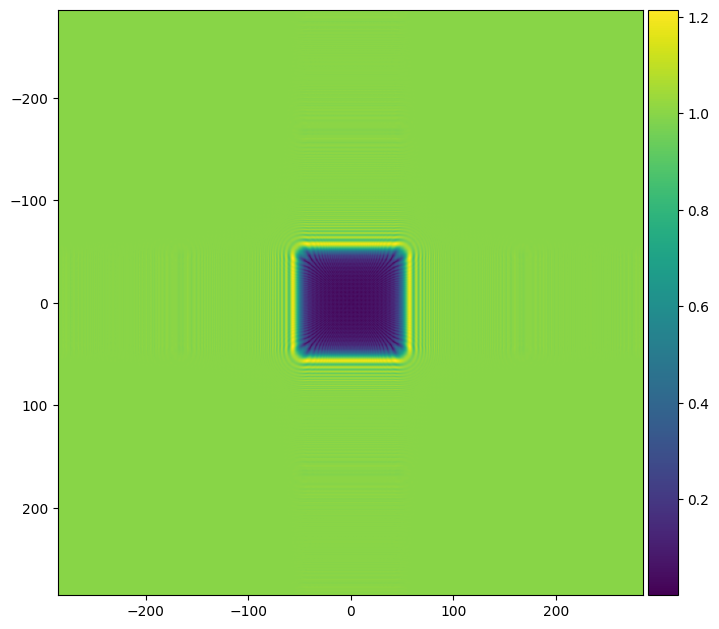

In [18]:
fig, ax = plt.subplots(figsize=(8,8))
im=ax.imshow(np.abs(res_tot.reshape(m,m)), cmap='viridis', extent=bbox)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax)